# Interactive Data Visualization...


## Daily Challenge: Interactive Data Visualization With Matplotlib And Seaborn



## 👩‍🏫 👩🏿‍🏫 What You’ll Learn

* Advanced data visualization techniques.
* Interactive chart creation using Matplotlib.
* Elegant static data presentation with Seaborn.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import warnings
warnings.filterwarnings("ignore", category=SyntaxWarning)

In [3]:
#@title 🔄 Colab & Local Jupyter Folder Switcher (click to expand)

# 🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨
# 🚨        Change only this 🚨
relative_path = "_datasets" #🚨 any relative path
# 🚨        Change only this 🚨
# 🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨

import os

create_if_missing = True      # False = error if folder missing

def in_colab() -> bool:
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False

def paths_equal(a: str, b: str) -> bool:
    """Portable path equality (no os.path.samepath)."""
    return os.path.normcase(os.path.realpath(a)) == os.path.normcase(os.path.realpath(b))

def resolve_local_base(rel_path: str) -> str:
    pinned = os.getenv("NOTEBOOK_ROOT")
    if pinned:
        return pinned
    cwd = os.path.abspath(os.getcwd())
    rel_name = os.path.basename(os.path.normpath(rel_path))
    base = os.path.dirname(cwd) if rel_name and os.path.basename(cwd) == rel_name else cwd
    os.environ["NOTEBOOK_ROOT"] = base
    return base

def resolve_colab_base(rel_path: str) -> str:
    pinned = os.getenv("COLAB_ROOT")
    if pinned:
        return pinned
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    mydrive = "/content/drive/MyDrive"
    colab_nb = os.path.join(mydrive, "Colab Notebooks")
    base = colab_nb if os.path.isdir(colab_nb) else mydrive
    os.environ["COLAB_ROOT"] = base
    return base

# --- Pick base path ---
if in_colab():
    print("✅ Detected Google Colab")
    base_path = resolve_colab_base(relative_path)
else:
    print("✅ Detected Local Jupyter")
    base_path = resolve_local_base(relative_path)

# --- Build target path ---
if os.path.isabs(relative_path):
    target_path = os.path.abspath(relative_path)
else:
    target_path = os.path.abspath(os.path.join(base_path, relative_path))

current = os.path.abspath(os.getcwd())
rel_name = os.path.basename(os.path.normpath(relative_path))
if rel_name and os.path.basename(current) == rel_name:
    target_path = current

# --- Ensure exists ---
if not os.path.exists(target_path):
    if create_if_missing:
        os.makedirs(target_path, exist_ok=True)
        print(f"📁 Created folder: {target_path}")
    else:
        raise FileNotFoundError(f"❌ Path does not exist: {target_path}")

# --- Change only if needed ---
if paths_equal(current, target_path):
    print(f"📂 Already working in: {current}")
else:
    os.chdir(target_path)
    print(f"📂 Now working in: {os.path.abspath(os.getcwd())}")


✅ Detected Local Jupyter
📂 Now working in: /Users/jayklarin/Documents/__DI/Repositories/di_bootcamp/Colab-Swap/_datasets


## 1. Data Preparation:

* Download and explore the US Superstore data.
* Perform basic data cleaning and preprocessing.

In [5]:
df = pd.read_excel('US Superstore data.xls')
df.head(3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [7]:
df.describe(include='all').transpose()

# No Missing Values (same dataset as mini-project)

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Row ID,9994.0,NaN,NaN,NaN,4997.5,1.0,2499.25,4997.5,7495.75,9994.0,2885.163629
Order ID,9994,5009,CA-2017-100111,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order Date,9994,NaN,NaN,NaN,2016-04-30 00:07:12.259355648,2014-01-03 00:00:00,2015-05-23 00:00:00,2016-06-26 00:00:00,2017-05-14 00:00:00,2017-12-30 00:00:00,NaN
Ship Date,9994,NaN,NaN,NaN,2016-05-03 23:06:58.571142912,2014-01-07 00:00:00,2015-05-27 00:00:00,2016-06-29 00:00:00,2017-05-18 00:00:00,2018-01-05 00:00:00,NaN
Ship Mode,9994,4,Standard Class,5968,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer ID,9994,793,WB-21850,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Name,9994,793,William Brown,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Segment,9994,3,Consumer,5191,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,9994,1,United States,9994,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,9994,531,New York City,915,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Data Visualization With Matplotlib:

* Create an interactive line chart to show sales trends over the years.
* Build an interactive map to visualize sales distribution by country.




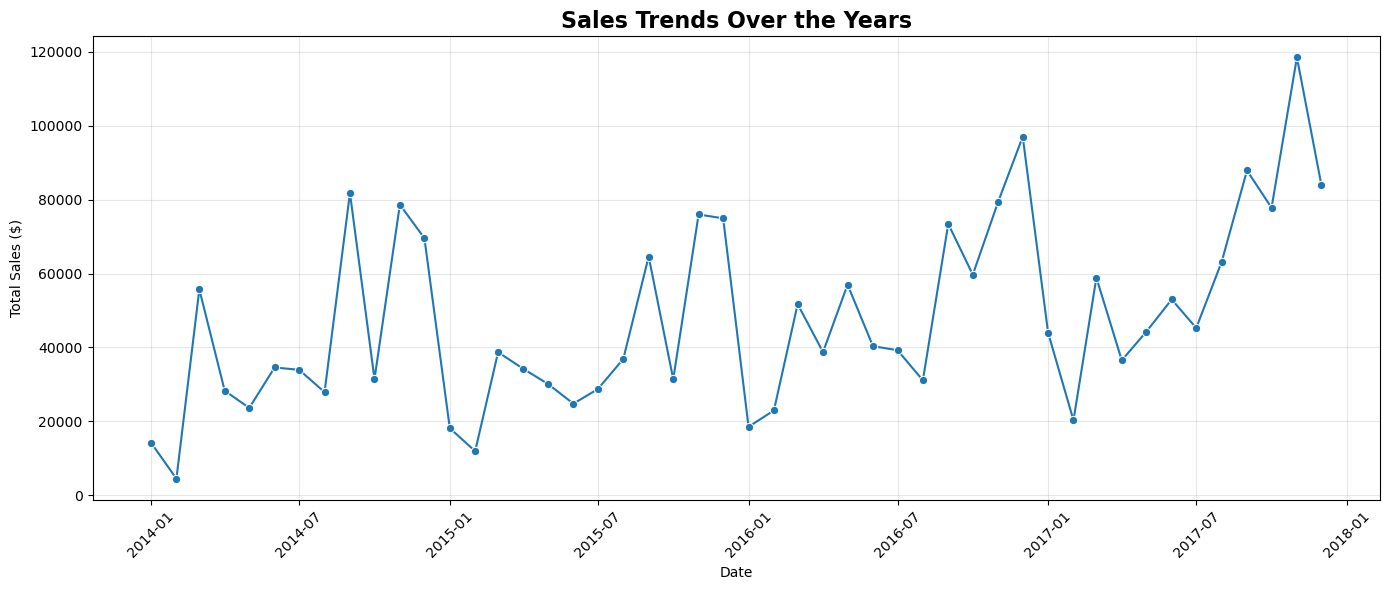

In [9]:
# Aggregate monthly sales
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()
monthly_sales.index = monthly_sales.index.to_timestamp()  # convert PeriodIndex → Timestamp

# Plot
plt.figure(figsize=(14, 6))
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values, marker="o")

# Plot Formatting
plt.title("Sales Trends Over the Years", fontsize=16, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Total Sales ($)")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### What is this showing us?
* This sales chart is showing us montly trends over the course of 4 years.  
* We get sales spikes when kids are going back to school and around the holidays.

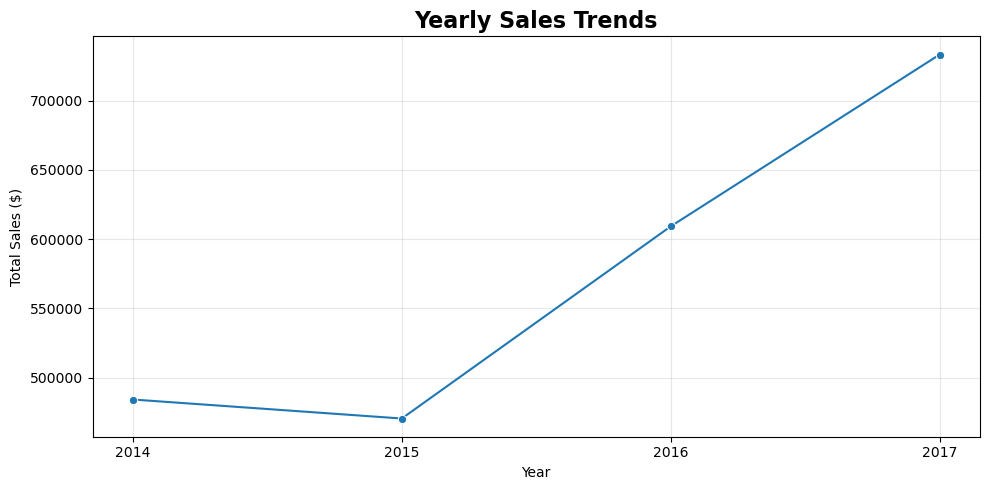

In [14]:
# Group sales data by year (extracted from 'Order Date')
# and calculate the total sales for each year
yearly_sales = df.groupby(df['Order Date'].dt.year)['Sales'].sum()

# Convert the index (which contains years) to integers
# so they display as clean whole numbers on the x-axis
yearly_sales.index = yearly_sales.index.astype(int)

# --- Visualization ---

# Create a new figure with custom size (10 inches wide x 5 inches tall)
plt.figure(figsize=(10, 5))

# Plot a line chart:
#   x-axis → Years (from the index)
#   y-axis → Total Sales values
#   marker="o" adds circular markers at each data point
sns.lineplot(x=yearly_sales.index, y=yearly_sales.values, marker="o")

# --- Plot Formatting ---

# Add a descriptive title with larger, bold font
plt.title("Yearly Sales Trends", fontsize=16, fontweight="bold")

# Label the x and y axes
plt.xlabel("Year")
plt.ylabel("Total Sales ($)")

# Add a light grid for better readability
plt.grid(True, alpha=0.3)

# Force x-axis ticks to exactly match the years in the index
plt.xticks(yearly_sales.index)

# Adjust the layout so titles, labels, and chart elements fit neatly
plt.tight_layout()

# Display the final plot
plt.show()


## This chart is showing the that since 2015 our sales have been steadily rising.  

In [ ]:
# --- 1) Prep data ------------------------------------------------------------
# Make sure Country is clean text
df['Country'] = df['Country'].astype(str).str.strip()

# Aggregate metrics by country (add more metrics to hover as you like)
country_stats = (
    df.groupby('Country', as_index=False)
      .agg(Sales=('Sales','sum'),
           Profit=('Profit','sum'),
           Quantity=('Quantity','sum'))
      .sort_values('Sales', ascending=False)
)

# --- 2) Build interactive choropleth ----------------------------------------
fig = px.choropleth(
    country_stats,
    locations='Country',            # uses full country names
    locationmode='country names',
    color='Sales',
    hover_name='Country',
    hover_data={'Sales':':,.0f', 'Profit':':,.0f', 'Quantity':':,', 'Country':False},
    color_continuous_scale='Viridis',
    title='Sales Distribution by Country'
)

# Optional: nicer geo styling
fig.update_layout(
    geo=dict(showframe=False, showcoastlines=True, projection_type='natural earth'),
    coloraxis_colorbar=dict(title='Sales')
)

fig.show()


In [ ]:
df['Country'].value_counts()

## It looks like our whole distribution network is in the United States

### 3. Data Visualization With Seaborn:

* Use Seaborn to generate a bar chart showing top 10 products by sales.
* Create a scatter plot to analyze the relationship between profit and discount.




In [ ]:
# Group data by product name, sum the sales for each product,
# sort results in descending order of sales,
# and reset the index so Product Name is a regular column in a dataframe
top_10_products_by_sales = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).reset_index()
top_10_products_by_sales = top_10_products_by_sales.head(10)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_10_products_by_sales,
    x='Sales',
    y='Product Name'
)

# Plot Formatting
plt.title('Top 10 Products by Sales', fontsize=16, fontweight='bold')
plt.xlabel('Total Sales ($)')
plt.ylabel('Product Name')
plt.tight_layout()

plt.show()

## These are our top 10 best selling products of all time.  

In [ ]:
# Extract only the Profit and Discount columns from the DataFrame
# We'll use this subset for plotting
profit_and_discount = df[['Profit', 'Discount']]

# --- Visualization ---

# Create a new figure with a custom size (10 inches wide x 6 inches tall)
plt.figure(figsize=(10,6))

# Create a scatter plot:
#   X-axis -> Discount values
#   Y-axis -> Profit values
sns.scatterplot(
    data=profit_and_discount,
    x='Discount',
    y='Profit'
)

# Add a descriptive title with larger, bold font
plt.title('Relationship Between Profit and Discount', fontsize=16, fontweight='bold')

# Label the X and Y axes
plt.xlabel('Discount')
plt.ylabel('Profit')

# Add a light grid for better readability (alpha controls transparency)
plt.grid(True, alpha=0.3)

# Adjust layout so titles, labels, and plot fit well without overlap
plt.tight_layout()

# Display the scatter plot
plt.show()


## In gerneral the larger the discount, the lower the profit. 
But as there is a spread for each discount amount, some of the higher discounts have higher profits.  Still, the general trend is the larger the discount, the higher the profit

## 4. Comparative Analysis:

* Compare the insights gained from Matplotlib and Seaborn visualizations.
* Document your observations about the ease of use and effectiveness of both tools.

In [ ]:
# Matplotlib

# Plot
plt.scatter(df['Discount'], df['Profit'], alpha=0.6)

# Plot Formatting
plt.xlabel("Discount")
plt.ylabel("Profit")

In [ ]:
# Seaborn
# Plot (with formatting built in)
sns.scatterplot(data=df, x='Discount', y='Profit')

### Document your observations about the ease of use and effectiveness of both tools.

#### Matplotlib is 
* more complex to use and more customizable than Seaborn
* great for customized final presentations
* the style is bare bones before adding custom styling
* able to tweak transparency - easier to see points clustered together
* requires user to name axis

#### Seaborn is
* simple to use
* great for quick analysis
* not as customizable as Matplotlib
* automatically names axis

## 5. Code And Insights:

* Write clear, well-documented Python code.
* Include your analysis and insights as comments or markdown cells in your Jupyter notebook.

In [ ]:
# I added a 'What is this showing us?' note after each chart
# Went back and documented my code.